In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os.path as path
import utils
import matplotlib.pyplot as plt
from collections import Counter

In [12]:
lau_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "drought_days_lau.geojson"))
nuts3_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "nuts3_stats.geojson"))
country_df = pd.read_json(path.join(utils.out_data_dir, "country_stats.geojson"))

In [13]:
# all percentages are between 0 and 100
assert((nuts3_df["cropland_area_percent"].dropna() <= 100).all())
assert((nuts3_df["cropland_area_percent"].dropna() >= 0).all())

In [14]:
# all computed drought day values must be between 0 and 365
for col in ["max_drought_days", "median_drought_days"]:
    for temp_df in [nuts3_df, lau_df]:
        assert (temp_df[col].dropna() < 365).all()
        assert (temp_df[col].dropna() >= 0).all()

In [15]:
actual_countries = list(set(nuts3_df["cntr_code"].values))
# All EU + EEA country codes and the UK. From here:
# https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Country_codes
eea_countries = [
    "BE",
    "BG",
    "CZ",
    "DK",
    "DE",
    "EE",
    "IE",
    "EL",
    "ES",
    "FR",
    "HR",
    "IT",
    "CY",
    "LV",
    "LT",
    "LU",
    "HU",
    "MT",
    "NL",
    "AT",
    "PL",
    "PT",
    "RO",
    "SI",
    "SK",
    "FI",
    "SE",
    "IS",
    "LI",
    "NO",
    "CH",
]
assert len(eea_countries) == 31

other_countries = [
    "UK", # uk, manually added
    "RS", # slovakia, albania, north macedonia are in the NUTS and LAU dataset, despite not being in the EEA
    "AL",
    "MK",
]
expected_countries = eea_countries + other_countries

assert sorted(expected_countries) == sorted(actual_countries)



In [16]:
nuts3_df.dropna(subset="cropland_area_percent").sort_values(by="cropland_area_percent", ascending=False)

,nuts_id,cntr_code,name_latn,nuts_name,area_km2,population,cropland_km2,cropland_km2_by_type,cropland_area_percent,warning_days,...,Drought days 2017,Drought days 2018,Drought days 2019,Drought days 2020,Drought days 2021,Drought days 2022,Drought days 2023,Drought days 2024,Drought days 2025,geometry
1185,RS125,RS,Severnobačka oblast,Севернобачка област,1784.32,157170.0,1414.00,"{'Wheat': 322.02, 'Barley': 222.55, 'Maize': 4...",79.25,"[181.91, 19.68, 0.0, 13.94, 0.0, 86.43, 4.74, ...",...,116.38,4.97,64.97,49.56,1.15,170.57,0.08,164.10,181.24,"POLYGON ((19.66071 46.1892, 19.68341 46.18001,..."
1163,RO312,RO,Călăraşi,Călăraşi,5078.66,278602.0,4011.83,"{'Wheat': 1205.91, 'Barley': 433.33, 'Maize': ...",78.99,"[37.45, 5.48, 0.0, 0.44, 0.12, 0.02, 27.58, 90...",...,0.02,32.39,99.73,276.09,4.78,187.97,276.35,239.50,101.54,"POLYGON ((26.72348 44.53797, 26.75057 44.52883..."
1166,RO315,RO,Ialomiţa,Ialomiţa,4455.58,248786.0,3498.19,"{'Wheat': 1034.11, 'Barley': 265.03, 'Maize': ...",78.51,"[53.45, 5.66, 0.16, 2.2, 0.0, 0.0, 39.55, 178....",...,0.14,45.46,191.41,280.03,4.28,156.50,201.61,221.84,108.52,"POLYGON ((26.61895 44.83328, 26.63093 44.81359..."
1168,RO317,RO,Teleorman,Teleorman,5786.99,313033.0,4358.58,"{'Wheat': 1739.37, 'Barley': 317.14, 'Maize': ...",75.32,"[112.14, 154.74, 1.94, 6.91, 0.22, 0.33, 3.23,...",...,0.33,8.86,46.22,226.67,32.22,275.52,278.89,344.70,138.80,"POLYGON ((25.44462 44.46683, 25.46331 44.45907..."
549,DEG0D,DE,Sömmerda,Sömmerda,805.78,67693.0,589.23,"{'Wheat': 216.4, 'Barley': 129.17, 'Maize': 62...",73.13,"[94.34, 0.36, 1.05, 113.55, 79.71, 47.87, 182....",...,65.06,196.07,359.88,299.09,25.03,174.92,129.62,0.00,51.14,"POLYGON ((11.10779 51.31099, 11.10777 51.30925..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,IS002,IS,Landsbyggð,Landsbyggð,101650.66,140390.0,15.19,"{'Fresh Vegetables': 7.65, 'Rapeseed': 2.03, '...",0.01,"[28.5, 11.21, 10.55, 7.72, 16.72, 58.57, 90.45...",...,59.02,92.51,148.22,42.15,66.06,30.08,39.04,32.42,47.22,"MULTIPOLYGON (((-16.01684 66.53358, -16.00103 ..."
1032,NO074,NO,Troms og Finnmark,Troms og Finnmark,74774.22,242452.0,6.37,"{'Barley': 0.34, 'Other cereals': 0.17, 'Fresh...",0.01,"[15.07, 55.88, 79.38, 64.29, 68.07, 19.83, 41....",...,24.67,42.50,45.04,31.37,60.19,50.93,67.46,72.72,48.92,"MULTIPOLYGON (((31.16727 70.38563, 31.16523 70..."
40,AT331,AT,Außerfern,Außerfern,1237.31,33946.0,0.00,{},0.00,"[27.2, 28.57, 32.3, 88.21, 30.03, 34.05, 103.6...",...,34.10,104.68,19.76,45.96,26.82,45.17,56.64,22.92,53.07,"MULTIPOLYGON (((10.43954 47.52466, 10.45444 47..."
852,IS001,IS,Höfuðborgarsvæði,Höfuðborgarsvæði,1046.05,249054.0,0.01,{'Unclassified annual crop': 0.01},0.00,"[27.65, 26.81, 34.76, 31.74, 51.74, 92.06, 144...",...,93.05,145.77,206.22,42.96,117.01,15.12,46.84,64.65,58.19,"MULTIPOLYGON (((-21.37005 64.38033, -21.37552 ..."


# sanity check: Top regions by agricultural percent

Severnobačka oblast - The north of Serbia is dominated by agriculture, as seen on [satellite](https://www.google.com/maps/place/Severna,+Ba%C4%8Dka+Topola,+Serbien/@45.7441886,19.5252855,65119m/data=!3m1!1e3!4m6!3m5!1s0x4744a984285dc461:0xada67651fd1d4157!8m2!3d45.8190391!4d19.6379201!16s%2Fg%2F1tdpdzmz?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D) 

Călăraşi - is almost exclusively fielsd as confirmed visually on the areas around the city on [google maps](https://www.google.com/maps/place/C%C4%83l%C4%83ra%C8%99i,+Rum%C3%A4nien/@44.242746,27.1900369,45330m/data=!3m1!1e3!4m6!3m5!1s0x40b022bcd70432fb:0x214283a3c0ceb78d!8m2!3d44.2085144!4d27.3137439!16zL20vMDI0Xzht?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

More Romanian municipalities follow, which all reflect a highly agriculturally intensive country. See below

Sömmerda in Germany makes the list with over 70% agricultural area, which also checks out when looking at [satellite data](https://www.google.com/maps/place/S%C3%B6mmerda/@51.1587729,11.1158043,11040m/data=!3m1!1e3!4m6!3m5!1s0x47a43ff535f08dd3:0x4208ec174358e70!8m2!3d51.1594582!4d11.1188764!16zL20vMDU4bG1w?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

# Bottom regions by agricultural percent
Höfuðborgarsvæði - capital region of Iceland containing Reykjavik, seems plausible

Lappi - Northernmost parts of Finland are hostile to many crops

Außerfern - high up in the [austrian alps](https://www.google.com/maps/place/Reutte,+%C3%96sterreich/@47.3842441,10.5190884,20932m/data=!3m1!1e3!4m6!3m5!1s0x479cea2f08bf6609:0x40f65c3c860d7ee2!8m2!3d47.3927114!4d10.5845109!16zL20vMDZzazA4?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

Troms og Finnmark - also known as Nordkap in the far north of Norway, checks out.

# General country-level cropland stats
Note: we expect our data to underestimate all cropland statistics. The High resolution layer croplands does not account for fallow lands (Brachland), which varies strongly between years. Before 2024, at least 4% of all agricultural area were required to lie fallow [as per EU rules](https://www.landwirtschaft.de/umwelt/natur/biodiversitaet/flaechenstilllegung-ausgesetzt-die-folgen-fuer-landwirtschaft-und-umwelt).

In [17]:
# https://www.destatis.de/DE/Themen/Branchen-Unternehmen/Landwirtschaft-Forstwirtschaft-Fischerei/Feldfruechte-Gruenland/_inhalt.html#:~:text=Etwa%20die%20H%C3%A4lfte%20der%20Fl%C3%A4che%20Deutschlands%20ist,dominiert%20der%20Anbau%20von%20Getreide%20zur%20K%C3%B6rnergewinnung.
# UN stat: Cropland Area in the EU is 118810 km^2 
nuts3_df[nuts3_df["cntr_code"] == "DE"]["cropland_km2"].sum()

np.float64(112229.78)

In [18]:
# https://statbase.org/data/rou-cropland/
# UN stat: 88130 # TODO: this discrepancy seems too high
nuts3_df[nuts3_df["cntr_code"] == "RO"]["cropland_km2"].sum()

np.float64(76041.45999999999)

In [19]:
# https://statbase.org/data/bgr-cropland/
# UN stat: 36225
nuts3_df[nuts3_df["cntr_code"] == "BG"]["cropland_km2"].sum()

np.float64(34389.3)

# Sanity checking hotspots on the map

- Central Poland had a severe dry spell in 2019 about which a [case study](https://www.mdpi.com/2073-4433/12/11/1475) was published
- The border between CH and FR along the river Doubs is also [frequently](https://phys.org/news/2023-10-river-drought-hit-france.html) [struck](https://www.bbc.com/news/world-europe-62483293)
- Almeria and Granada in southern Spain are known [drought hotspots](https://euroweeklynews.com/2025/01/06/almeria-faces-critical-water-shortage-as-drought-deepens/)
- The 2025 spring drought in Sweden is also [reported on](https://www.lemonde.fr/en/environment/article/2025/05/25/a-spring-without-rain-northern-europe-faces-exceptional-early-drought_6741641_114.html)

# Sanity check: distribution of median and max drought days in LAUs and NUTS-3

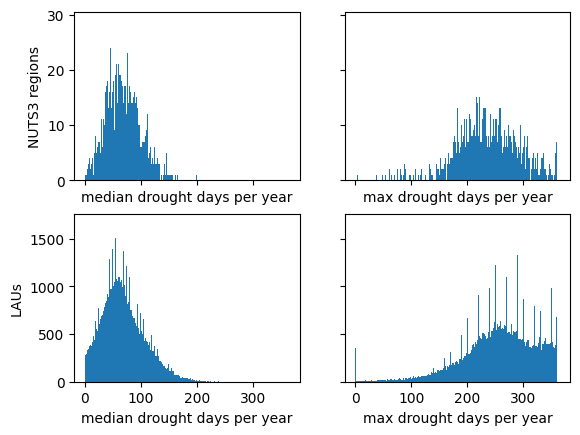

In [20]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey="row")

for i, metric in enumerate(["median", "max"]):
    axs[0][i].hist(nuts3_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[0][i].set_xlabel(f"{metric} drought days per year")

    axs[1][i].hist(lau_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[1][i].set_xlabel(f"{metric} drought days per year")
    
axs[0][0].set_ylabel("NUTS3 regions")
axs[1][0].set_ylabel("LAUs")
plt.show()